# Лабораторная работа № 5

# Многомерная регрессия

## Прогноз цены продажи домов

Датасет — `homes.csv`.

Набор данных предназначен для прогнозирования цены продажи домов с учетом различных факторов, таких как площадь, количество комнат, возраст дома, размер участка и налоги. Он представляет собой практическую задачу для специалистов по машинному обучению, особенно для тех, кто интересуется недвижимостью и анализом рынка.

Признаки:
- **Sell** — цена продажи дома (в тыс. долларов США) — целевая переменная;
- **List** — запрашиваемая цена (в тыс. долларов США);
- **Living** — жилая площадь (в сотнях квадратных футов);
- **Rooms** — общее количество комнат;
- **Beds** — количество спален;
- **Baths** — количество ванных комнат;
- **Age** — возраст дома (в годах);
- **Acres** — размер участка (в акрах);
- **Taxes** — годовой налог на недвижимость (в долларах США).

# 0 шаг. Импортируем библиотеки и загружаем данные

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('homes.csv')

Saving homes.csv to homes.csv


In [4]:
df.head()

,Sell,List,Living,Rooms,Beds,Baths,Age,Acres,Taxes
0,142,160,28,10,5,3,60,0.28,3167
1,175,180,18,8,4,1,12,0.43,4033
2,129,132,13,6,3,1,41,0.33,1471
3,138,140,17,7,3,1,22,0.46,3204
4,232,240,25,8,4,3,5,2.05,3613


In [7]:
print("Размер данных:", df.shape)

Размер данных: (50, 9)


> По первым строкам видно, что датасет содержит сведения о домах: запрашиваемая цена, жилая площадь, количество комнат, спален, ванных, возраст дома, размер участка и налоги.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sell    50 non-null     int64  
 1   List    50 non-null     int64  
 2   Living  50 non-null     int64  
 3   Rooms   50 non-null     int64  
 4   Beds    50 non-null     int64  
 5   Baths   50 non-null     int64  
 6   Age     50 non-null     int64  
 7   Acres   50 non-null     float64
 8   Taxes   50 non-null     int64  
dtypes: float64(1), int64(8)
memory usage: 3.6 KB


> По результату `df.info()` видно, что в датасете есть числовые признаки типа `int64` и `float64`. Все столбцы содержат 50 записей, пропущенные значения отсутствуют, поэтому дополнительная обработка пропусков не требуется.

In [9]:
df.describe()

,Sell,List,Living,Rooms,Beds,Baths,Age,Acres,Taxes
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,170.360000,178.340000,21.120000,8.060000,3.820000,1.860000,30.220000,1.020600,3706.100000
std,72.755885,79.382723,8.351072,1.284285,0.690755,0.756199,30.962314,1.191496,1579.915268
min,87.000000,90.000000,10.000000,5.000000,3.000000,1.000000,2.000000,0.220000,1445.000000
25%,135.000000,140.000000,17.000000,7.000000,3.000000,1.000000,12.250000,0.382500,3107.000000
50%,152.000000,160.000000,20.000000,8.000000,4.000000,2.000000,24.500000,0.550000,3490.000000
75%,182.250000,190.000000,22.750000,9.000000,4.000000,2.000000,37.000000,1.182500,3919.250000
max,567.000000,625.000000,64.000000,12.000000,6.000000,4.000000,202.000000,6.490000,12192.000000


> Метод `describe()` показывает основные статистические характеристики числовых признаков. Целевая переменная `Sell` принимает значения от 87 до 567 тыс. долларов

# 1 шаг. Проанализируем целевую переменную

Для начала проанализируем распределение целевой переменной `Sell`, так как именно это значение будет прогнозировать модель линейной регрессии.

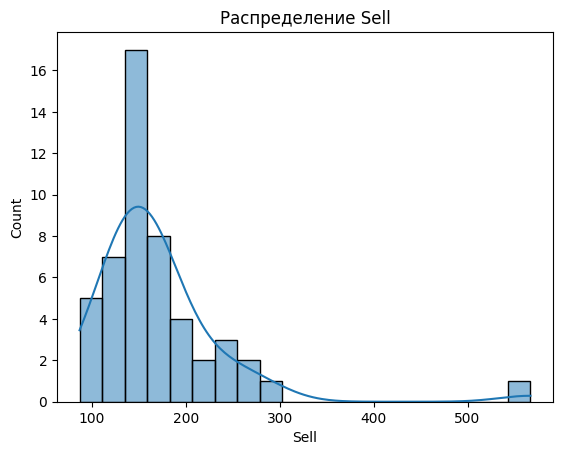

In [10]:
sns.histplot(df['Sell'], bins=20, kde=True, color='C0')
plt.title('Распределение Sell')
plt.show()

> По графику видно, что целевая переменная `Sell` имеет распределение с пиком в районе 130-180 тыс. долларов.

# 2 шаг. Произведем разведочный анализ данных

### Влияние жилой площади на цену продажи

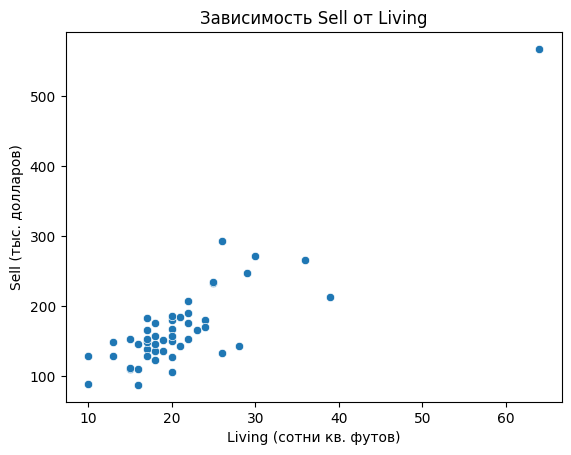

In [11]:
sns.scatterplot(x=df['Living'], y=df['Sell'])
plt.title('Зависимость Sell от Living')
plt.xlabel('Living (сотни кв. футов)')
plt.ylabel('Sell (тыс. долларов)')
plt.show()

> По графику видно, что при увеличении жилой площади цена продажи обычно также увеличивается. Это логично, так как большая площадь дома обычно требует более высокой цены. Следовательно, признак `Living` может быть важным для построения модели.

### Влияние возраста дома на цену продажи

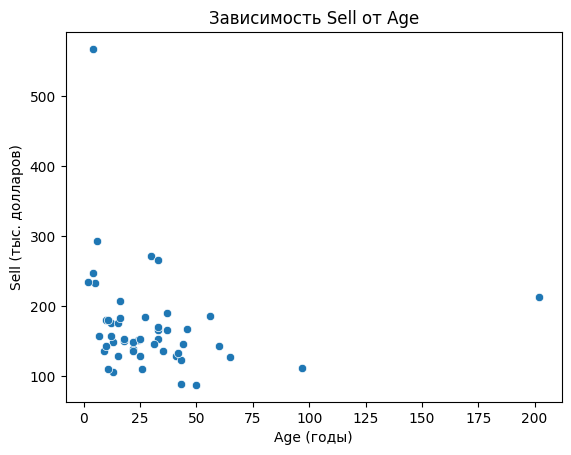

In [12]:
sns.scatterplot(x=df['Age'], y=df['Sell'])
plt.title('Зависимость Sell от Age')
plt.xlabel('Age (годы)')
plt.ylabel('Sell (тыс. долларов)')
plt.show()

> По графику видно, что между возрастом дома и ценой продажи нет явной линейной зависимости. Есть как старые дома с высокой ценой, так и новые с низкой. Однако можно заметить, что большинство дорогих домов имеют возраст менее 40 лет. Признак `Age` может иметь слабое влияние на целевую переменную.

### Влияние размера участка на цену продажи

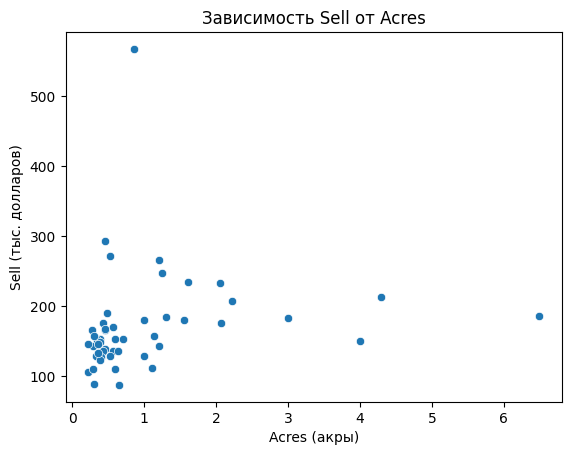

In [13]:
sns.scatterplot(x=df['Acres'], y=df['Sell'])
plt.title('Зависимость Sell от Acres')
plt.xlabel('Acres (акры)')
plt.ylabel('Sell (тыс. долларов)')
plt.show()

### Влияние налогов на цену продажи

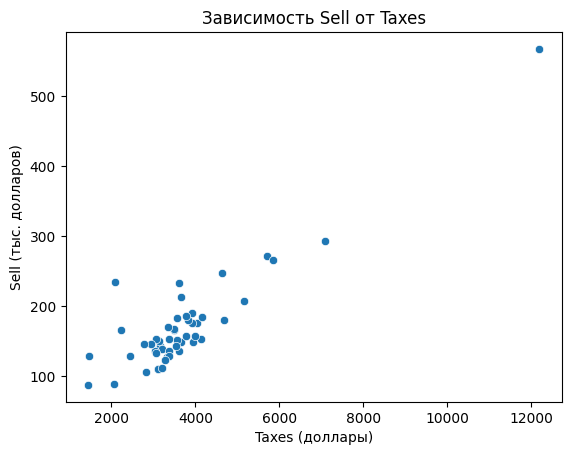

In [14]:
sns.scatterplot(x=df['Taxes'], y=df['Sell'])
plt.title('Зависимость Sell от Taxes')
plt.xlabel('Taxes (доллары)')
plt.ylabel('Sell (тыс. долларов)')
plt.show()

> По графику видно, что дома с более высокими налогами обычно имеют более высокую цену продажи. Это может быть связано с тем, что дорогие дома находятся в районах с более высокими налоговыми ставками. Признак `Taxes` может быть важным для прогнозирования цены.

### Корреляция числовых признаков

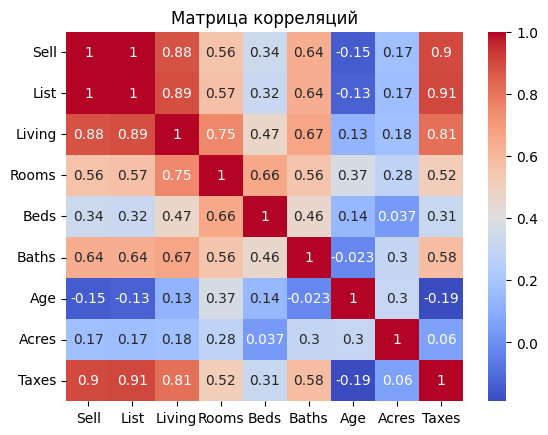

In [15]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

> Матрица корреляций позволяет оценить связь числовых признаков с целевой переменной `Sell`. Наибольшую положительную корреляцию с целевой переменной имеют признаки `Living` , `List`  и `Taxes` . Признак `Age` имеет отрицательную корреляцию (-0.15)

# 3 шаг. Удалим несущественные признаки

In [16]:
df_copy = df.copy()
# Все признаки могут влиять на цену продажи, поэтому оставим их все
df_copy.head()

,Sell,List,Living,Rooms,Beds,Baths,Age,Acres,Taxes
0,142,160,28,10,5,3,60,0.28,3167
1,175,180,18,8,4,1,12,0.43,4033
2,129,132,13,6,3,1,41,0.33,1471
3,138,140,17,7,3,1,22,0.46,3204
4,232,240,25,8,4,3,5,2.05,3613


# 4 шаг. Проверяем наличие пропущенных значений

In [17]:
print(df_copy.isnull().sum())

Sell      0
List      0
Living    0
Rooms     0
Beds      0
Baths     0
Age       0
Acres     0
Taxes     0
dtype: int64


> Пропущенные значения в датасете отсутствуют, обработка пропусков не требуется.

# 5 шаг. Заменяем категориальные значения числовыми

В данном датасете все признаки уже представлены в числовом формате (`int64` и `float64`). Категориальные признаки отсутствуют, поэтому кодирование не требуется.

# 6 шаг. Разделяем данные на признаки и целевую переменную

In [19]:
y = df_copy['Sell']
X = df_copy.drop('Sell', axis=1)

# убедимся, что данные в нужном нам формате
type(X), type(y)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

In [20]:
# посмотрим на признаки
X.head()

,List,Living,Rooms,Beds,Baths,Age,Acres,Taxes
0,160,28,10,5,3,60,0.28,3167
1,180,18,8,4,1,12,0.43,4033
2,132,13,6,3,1,41,0.33,1471
3,140,17,7,3,1,22,0.46,3204
4,240,25,8,4,3,5,2.05,3613


> Данные были разделены на матрицу признаков `X` и целевую переменную `y`. В качестве целевой переменной используется столбец `Sell`, остальные столбцы используются как признаки.

# 7 шаг. Разделяем данные на обучающую и тестовую выборку

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

75% данных используется для обучения модели и 25% — для тестирования. Разделение выполнено с помощью функции `train_test_split`.

# 8 шаг. Применяем операцию нормализации для численной устойчивости

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler

StandardScaler()

## Масштабируем признаки обучающей и тестовой выборки

In [23]:
X_train_scaled = scaler.fit_transform(X_train)  # обучаем и преобразуем тренировочные
X_test_scaled = scaler.transform(X_test)        # преобразуем тестовые теми же параметрами

> Масштабирование признаков выполнено с помощью `StandardScaler`. Для обучающей выборки используется `fit_transform`, а для тестовой — `transform`, чтобы параметры масштабирования определялись только по обучающим данным.

# 9 шаг. Обучаем модель линейной регрессии

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(X_train_scaled, y_train)
model

LinearRegression()

> Модель линейной регрессии была обучена на масштабированных данных обучающей выборки.

# 10 шаг. Делаем прогноз на основе данных тестирования

In [25]:
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# выведем первые пять значений с помощью диапазона индексов
y_pred_test[:5]

array([593.16729421,  85.34304391, 142.2307439 , 114.23081941,
       131.26530901])

> Модель построила прогнозы для обучающей и тестовой выборок. Для проверки были выведены первые пять предсказанных значений на тестовой выборке.

# 11 шаг. Оценка качества

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(y_true, y_pred, set_name=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"=== {set_name} ===")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R2 : {r2:.4f}")
    print()

evaluate_model(y_train, y_pred_train, "Train set")
evaluate_model(y_test, y_pred_test, "Test set")

=== Train set ===
MSE: 12.44
RMSE: 3.53
MAE: 2.71
R2 : 0.9933

=== Test set ===
MSE: 76.29
RMSE: 8.73
MAE: 5.67
R2 : 0.9946



> Для оценки качества модели были использованы метрики `MSE`, `RMSE`, `MAE` и `R2`. На обучающей выборке модель получила значение `R2 = 0.9933`, а на тестовой выборке `R2 = 0.9946`. Это означает, что модель объясняет примерно **99.46%** изменчивости цены продажи на тестовых данных — это отличный показатель, свидетельствующий о высокой точности модели.
>
> Средняя абсолютная ошибка на тестовой выборке составила `MAE = 5.67` тыс. долларов, а корень из среднеквадратичной ошибки составил `RMSE = 8.73` тыс. долларов. Это означает, что в среднем модель ошибается примерно на **5-9 тыс. долларов**, что является хорошим результатом для прогнозирования цен на недвижимость.
>
> Значения метрик на обучающей и тестовой выборках близки, поэтому можно сделать вывод, что модель **не переобучилась** и хорошо обобщается на новых данных.

# 12 шаг. Итоговое уравнение

In [27]:
# Коэффициенты
print('Coefficients: ', model.coef_)

# Свободный член
print('Intercept: ', model.intercept_)

Coefficients:  [ 4.57482364e+01 -1.19535241e+00 -3.02417593e+00  2.89189704e+00
 -1.30632126e+00 -2.55947290e-01 -3.92055761e-02 -1.30578958e+00]
Intercept:  164.43243243243242


In [28]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,List,45.748236
1,Living,-1.195352
2,Rooms,-3.024176
3,Beds,2.891897
4,Baths,-1.306321
5,Age,-0.255947
6,Acres,-0.039206
7,Taxes,-1.305790


> - Признак **List** (запрашиваемая цена) имеет наибольший положительный коэффициент, что логично, так как продавцы обычно запрашивают цену, близкую к рыночной.
> - Признак **Beds** (количество спален) положительно влияет на цену: каждая дополнительная спальня увеличивает стоимость дома примерно на 2.89 тыс. долларов.
> - Признак **Age** (возраст дома) имеет небольшой отрицательный коэффициент (-0.26), что соответствует ожиданиям: чем старше дом, тем он дешевле.
> - Признаки **Rooms**, **Baths**, **Acres** и **Taxes** имеют небольшие отрицательные коэффициенты, что может быть связано с мультиколлинеарностью или небольшим размером выборки.

# 12 шаг. Остатки регрессии

Построим график остатков регрессии. Остатки показывают разницу между фактическими и предсказанными значениями целевой переменной. Такой график позволяет проверить, есть ли у ошибок модели выраженный систематический паттерн.

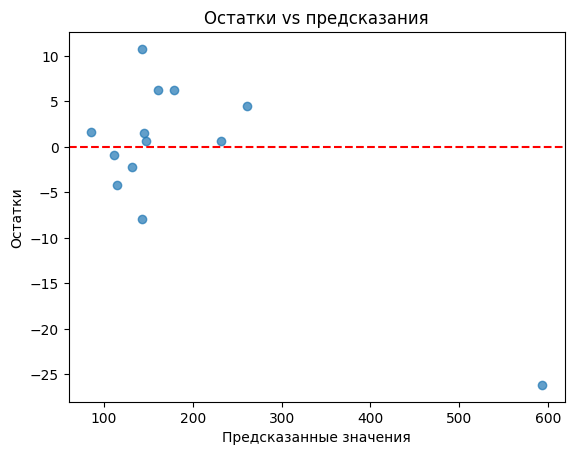

In [29]:
residuals = y_test - y_pred_test

plt.scatter(y_pred_test, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('Остатки vs предсказания')
plt.show()

> На графике остатки в основном расположены вокруг горизонтальной линии нуля. Это означает, что модель не имеет сильного систематического смещения в одну сторону. При этом заметны отдельные крупные ошибки, особенно для домов с высокой предсказанной ценой. В целом модель можно считать приемлемой.

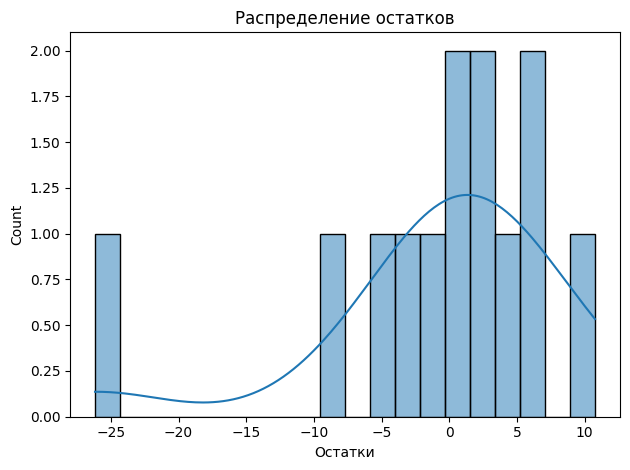

In [30]:
sns.histplot(residuals, bins=20, kde=True, color='C0')
plt.xlabel('Остатки')
plt.title('Распределение остатков')
plt.tight_layout()
plt.show()